In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Conv2D,
    MaxPooling2D
)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.5.3


In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


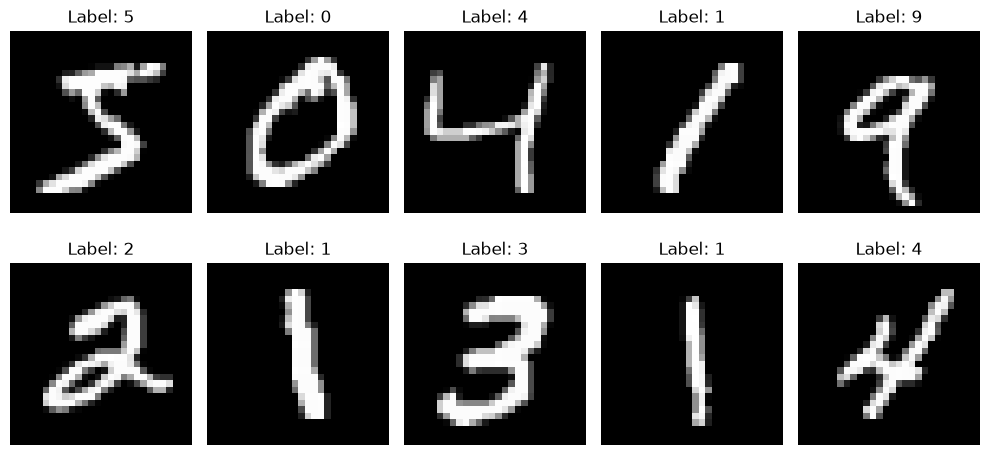

In [3]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Min:", X_train.min())
print("Max:", X_train.max())

Min: 0.0
Max: 1.0


In [5]:
mlp_model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(128, activation="relu"),

    Dense(64, activation="relu"),

    Dense(10, activation="softmax")
])

mlp_model.summary()

c:\Users\PC-LAB1\tarek\ovenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
mlp_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
history_mlp = mlp_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9267 - loss: 0.2537 - val_accuracy: 0.9657 - val_loss: 0.1113
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9680 - loss: 0.1054 - val_accuracy: 0.9717 - val_loss: 0.0934
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9773 - loss: 0.0734 - val_accuracy: 0.9760 - val_loss: 0.0829
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9825 - loss: 0.0543 - val_accuracy: 0.9768 - val_loss: 0.0797
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9869 - loss: 0.0422 - val_accuracy: 0.9792 - val_loss: 0.0801
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9886 - loss: 0.0356 - val_accuracy: 0.9743 - val_loss: 0.0904
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9904 - loss: 0.0289 - val_accuracy: 0.9782 - val_loss: 0.0832
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9929 - loss: 0.0226 - 

In [8]:
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("MLP Test Loss:", mlp_test_loss)
print("MLP Test Accuracy:", mlp_test_accuracy)

MLP Test Loss: 0.08292829245328903
MLP Test Accuracy: 0.978600025177002


In [9]:
predictions = mlp_model.predict(X_test)

predicted_class = np.argmax(predictions[0])

print("Predicted:", predicted_class)
print("Actual:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step
Predicted: 7
Actual: 7


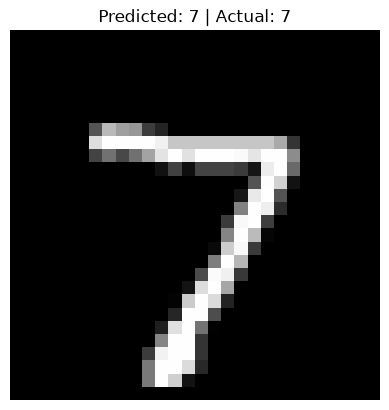

In [10]:
plt.imshow(X_test[0], cmap="gray")
plt.title(
    f"Predicted: {predicted_class} | Actual: {y_test[0]}"
)
plt.axis("off")
plt.show()

In [11]:
X_train_cnn = np.expand_dims(X_train, axis=-1)
X_test_cnn = np.expand_dims(X_test, axis=-1)

print(X_train_cnn.shape)
print(X_test_cnn.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [12]:
cnn_model = Sequential([
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dense(10, activation="softmax")
])

cnn_model.summary()

c:\Users\PC-LAB1\tarek\ovenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9565 - loss: 0.1414 - val_accuracy: 0.9875 - val_loss: 0.0486
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9858 - loss: 0.0460 - val_accuracy: 0.9893 - val_loss: 0.0404
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9900 - loss: 0.0323 - val_accuracy: 0.9900 - val_loss: 0.0348
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9927 - loss: 0.0227 - val_accuracy: 0.9897 - val_loss: 0.0373
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9947 - loss: 0.0166 - val_accuracy: 0.9892 - val_loss: 0.0409
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9956 - loss: 0.0133 - val_accuracy: 0.9913 - val_loss: 0.0360
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9970 - loss: 0.0099 - val_accuracy: 0.9897 - val_loss: 0.0494
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9968 - loss: 0.0094 

In [15]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    X_test_cnn,
    y_test,
    verbose=0
)

print("CNN Test Loss:", cnn_test_loss)
print("CNN Test Accuracy:", cnn_test_accuracy)

CNN Test Loss: 0.03501110523939133
CNN Test Accuracy: 0.9908999800682068


In [16]:
print("MLP Accuracy :", mlp_test_accuracy)
print("CNN Accuracy :", cnn_test_accuracy)

MLP Accuracy : 0.978600025177002
CNN Accuracy : 0.9908999800682068


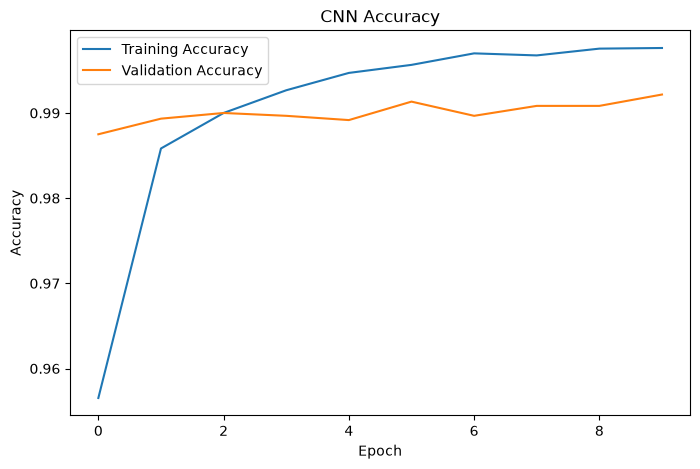

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history_cnn.history["accuracy"])
plt.plot(history_cnn.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.title("CNN Accuracy")
plt.show()

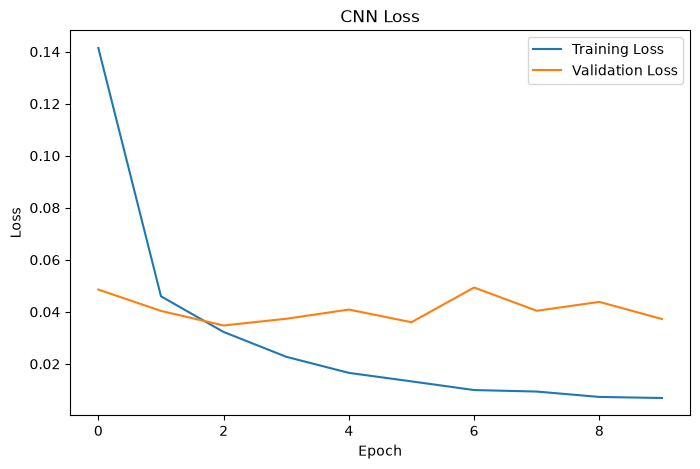

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history_cnn.history["loss"])
plt.plot(history_cnn.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.title("CNN Loss")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


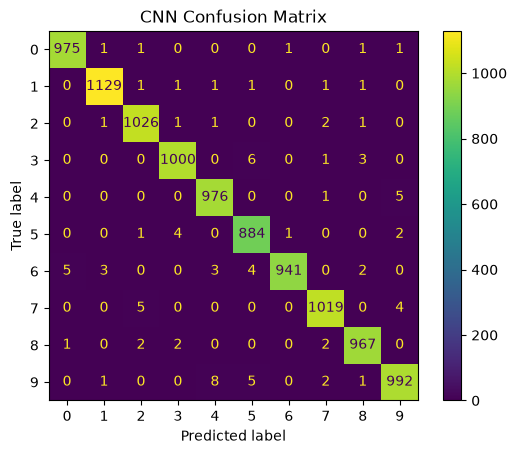

In [19]:
y_pred = cnn_model.predict(X_test_cnn)

y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("CNN Confusion Matrix")
plt.show()

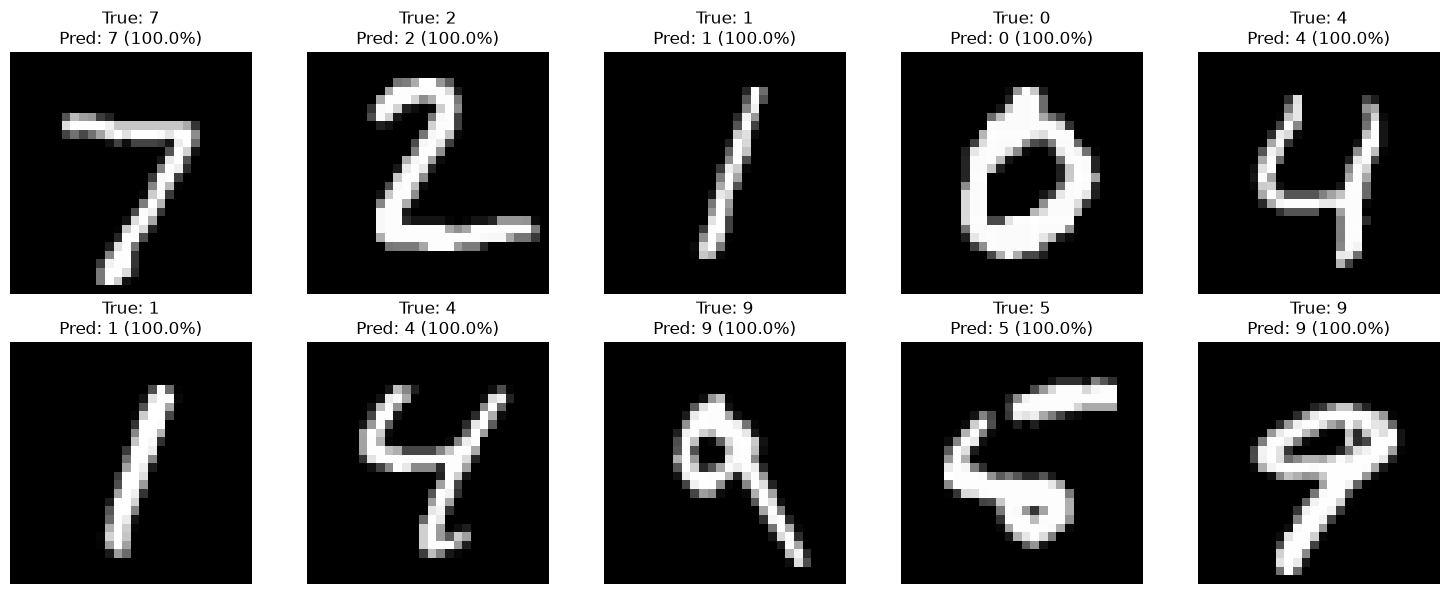

In [24]:
plt.figure(figsize=(15, 6))

for i in range(10):

    image = X_test_cnn[i]

    prediction = cnn_model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )

    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class] * 100

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(
        f"True: {y_test[i]}\n"
        f"Pred: {predicted_class} ({confidence:.1f}%)"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

In [28]:
dataset_dir = r"C:\cats_dogs"

train_dir = os.path.join(dataset_dir, "train")
validation_dir = os.path.join(dataset_dir, "validation")

print("Train directory:")
print(train_dir)

print("\nValidation directory:")
print(validation_dir)

Train directory:
C:\cats_dogs\train

Validation directory:
C:\cats_dogs\validation


In [29]:
print("Train exists:", os.path.exists(train_dir))
print("Validation exists:", os.path.exists(validation_dir))

Train exists: True
Validation exists: True


In [40]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=32,
    label_mode="binary"
)

Found 2000 files belonging to 2 classes.


In [42]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 2000 files belonging to 2 classes.


In [43]:
print("Classes:", train_ds.class_names)

Classes: ['cats', 'dogs']


In [44]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 128, 128, 3)
Labels shape: (32, 1)


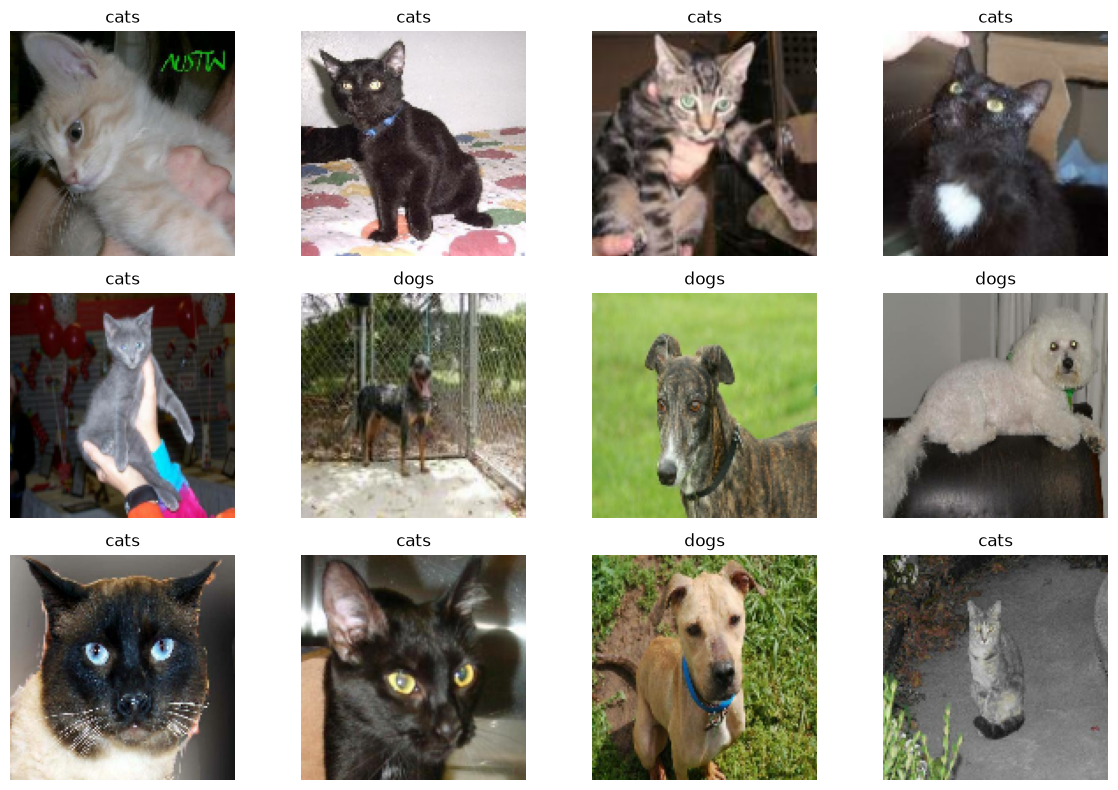

In [45]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label = int(labels[i].numpy()[0])

        plt.title(train_ds.class_names[label])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
model = tf.keras.Sequential([
    
    # Normalize pixel values: 0-255 → 0-1
    tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    # Convolution Block 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Convert feature maps to vector
    tf.keras.layers.Flatten(),

    # Fully Connected Layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Binary output
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

c:\Users\PC-LAB1\tarek\ovenv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [47]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [48]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


c:\Users\PC-LAB1\tarek\ovenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 467ms/step - accuracy: 0.5260 - loss: 0.7222 - val_accuracy: 0.5355 - val_loss: 0.6876
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 471ms/step - accuracy: 0.6060 - loss: 0.6702 - val_accuracy: 0.5460 - val_loss: 0.7169
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 419ms/step - accuracy: 0.6600 - loss: 0.6226 - val_accuracy: 0.6255 - val_loss: 0.6504
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 297ms/step - accuracy: 0.6855 - loss: 0.5859 - val_accuracy: 0.6495 - val_loss: 0.6538
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 279ms/step - accuracy: 0.7435 - loss: 0.5229 - val_accuracy: 0.6790 - val_loss: 0.6176
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step - accuracy: 0.7875 - loss: 0.4453 - val_accuracy: 0.6615 - val_loss: 0.6989
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 263ms/step - accuracy: 0.8270 - loss: 0.3769 - val_accuracy: 0.6570 - val_loss: 0.8297
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 265ms/step - accuracy: 0.8620 - loss: 0.3058 - val_accuracy: 0.661

In [50]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.6890 - loss: 1.1271
Validation Loss: 1.1271460056304932
Validation Accuracy: 0.6890000104904175


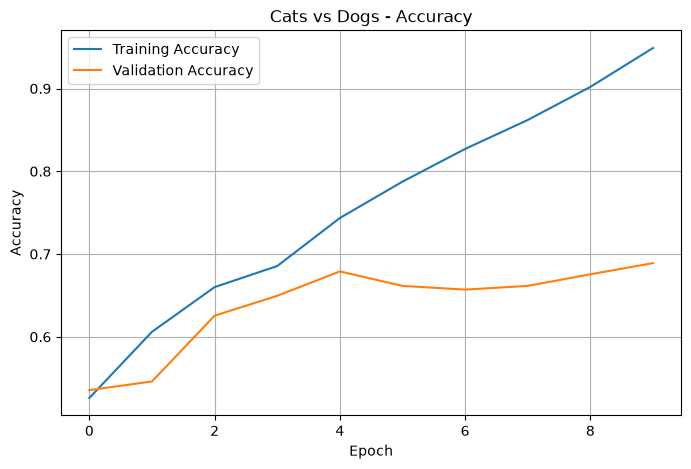

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Cats vs Dogs - Accuracy")

plt.legend()
plt.grid(True)

plt.show()

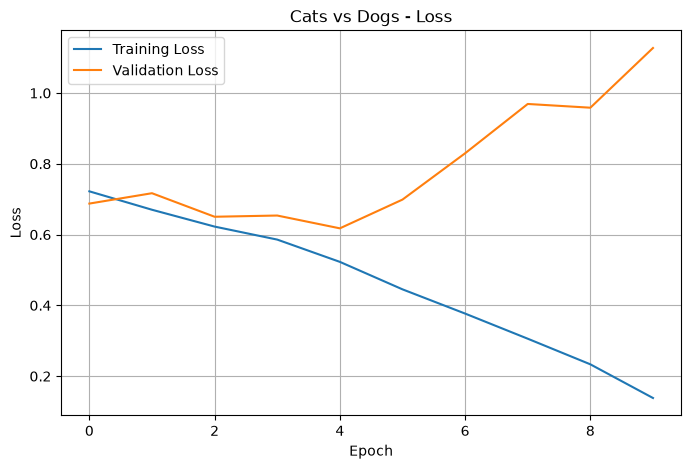

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cats vs Dogs - Loss")

plt.legend()
plt.grid(True)

plt.show()

Classes: ['cats', 'dogs']
Prediction: dogs
Score: 0.9987708330154419


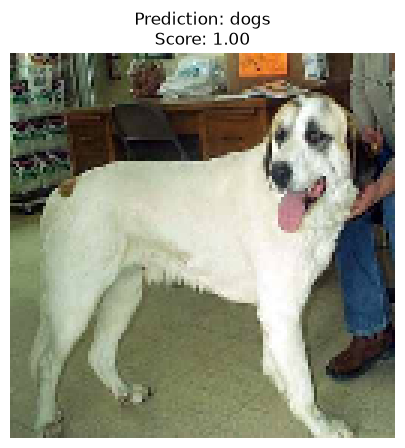

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# =========================
# 1. Classes
# =========================
class_names = train_ds.class_names

print("Classes:", class_names)

# =========================
# 2. Image path
# =========================
image_path = r"C:\tarek\dogs-vs-cats\test1\617.jpg"

# =========================
# 3. Load image
# =========================
img = load_img(
    image_path,
    target_size=(128, 128)
)

# =========================
# 4. Convert image to array
# =========================
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# =========================
# 5. Prediction
# =========================
prediction = model.predict(img_array, verbose=0)

prediction_value = float(prediction[0][0])

# =========================
# 6. Determine class
# =========================
predicted_index = int(prediction_value >= 0.5)
predicted_class = class_names[predicted_index]

# =========================
# 7. Print result
# =========================
print("Prediction:", predicted_class)
print("Score:", prediction_value)

# =========================
# 8. Display image
# =========================
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Score: {prediction_value:.2f}"
)
plt.show()

In [66]:
print("===== DATASET INFORMATION =====")

print("Classes:", train_ds.class_names)

print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))

for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)


    print("===== TRAINING RESULTS =====")

print("Epochs:", len(history.history["loss"]))

for i in range(len(history.history["loss"])):
    print(
        f"Epoch {i+1}: "
        f"Loss={history.history['loss'][i]:.4f}, "
        f"Accuracy={history.history['accuracy'][i]:.4f}, "
        f"Val Loss={history.history['val_loss'][i]:.4f}, "
        f"Val Accuracy={history.history['val_accuracy'][i]:.4f}"
    )



    best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_accuracy = max(history.history["val_accuracy"])

print("===== BEST RESULT =====")
print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)
print("Best Validation Accuracy (%):", best_val_accuracy * 100)




print("===== MODEL EVALUATION =====")

val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)
print("Validation Accuracy (%):", val_accuracy * 100)

print("===== MODEL INFORMATION =====")

model.summary()

===== DATASET INFORMATION =====
Classes: ['cats', 'dogs']
Training batches: 63
Validation batches: 63
Image shape: (32, 128, 128, 3)
Label shape: (32, 1)
===== TRAINING RESULTS =====
Epochs: 10
Epoch 1: Loss=0.7222, Accuracy=0.5260, Val Loss=0.6876, Val Accuracy=0.5355
Epoch 2: Loss=0.6702, Accuracy=0.6060, Val Loss=0.7169, Val Accuracy=0.5460
Epoch 3: Loss=0.6226, Accuracy=0.6600, Val Loss=0.6504, Val Accuracy=0.6255
Epoch 4: Loss=0.5859, Accuracy=0.6855, Val Loss=0.6538, Val Accuracy=0.6495
Epoch 5: Loss=0.5229, Accuracy=0.7435, Val Loss=0.6176, Val Accuracy=0.6790
Epoch 6: Loss=0.4453, Accuracy=0.7875, Val Loss=0.6989, Val Accuracy=0.6615
Epoch 7: Loss=0.3769, Accuracy=0.8270, Val Loss=0.8297, Val Accuracy=0.6570
Epoch 8: Loss=0.3058, Accuracy=0.8620, Val Loss=0.9690, Val Accuracy=0.6615
Epoch 9: Loss=0.2335, Accuracy=0.9020, Val Loss=0.9585, Val Accuracy=0.6755
Epoch 10: Loss=0.1383, Accuracy=0.9490, Val Loss=1.1271, Val Accuracy=0.6890
===== BEST RESULT =====
Best Epoch: 10
Best V

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,914,309 (37.82 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,609,540 (25.21 MB)

In [67]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [68]:
model_aug = tf.keras.Sequential([
    
    # Data Augmentation
    data_augmentation,

    # Normalize
    tf.keras.layers.Rescaling(1./255),

    # CNN Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # CNN Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # CNN Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Flatten
    tf.keras.layers.Flatten(),

    # Dense
    tf.keras.layers.Dense(128, activation="relu"),

    # Dropout
    tf.keras.layers.Dropout(0.5),

    # Output
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [69]:
model_aug.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [70]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [71]:
history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 276ms/step - accuracy: 0.5005 - loss: 0.6948 - val_accuracy: 0.5135 - val_loss: 0.6910
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.5110 - loss: 0.6918 - val_accuracy: 0.5855 - val_loss: 0.6727
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 466ms/step - accuracy: 0.5565 - loss: 0.6867 - val_accuracy: 0.6025 - val_loss: 0.6801
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 384ms/step - accuracy: 0.5920 - loss: 0.6658 - val_accuracy: 0.6120 - val_loss: 0.6865
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 397ms/step - accuracy: 0.6190 - loss: 0.6497 - val_accuracy: 0.6080 - val_loss: 0.6519
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 394ms/step - accuracy: 0.6440 - loss: 0.6320 - val_accuracy: 0.6410 - val_loss: 0.6699
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 472ms/step - accuracy: 0.6700 - loss: 0.6142 - val_accuracy: 0.6775 - val_loss: 0.6053
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 263ms/step - accuracy: 0.6740 - loss: 0.6001 - val_accu

In [72]:
val_loss_aug, val_accuracy_aug = model_aug.evaluate(
    val_ds,
    verbose=1
)

print("Validation Loss:", val_loss_aug)
print("Validation Accuracy:", val_accuracy_aug)
print("Validation Accuracy (%):", val_accuracy_aug * 100)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.7535 - loss: 0.5174
Validation Loss: 0.5174392461776733
Validation Accuracy: 0.7534999847412109
Validation Accuracy (%): 75.3499984741211


In [73]:
print("===== MODEL COMPARISON =====")

print(f"Old Model Accuracy: {val_accuracy * 100:.2f}%")
print(f"New Model Accuracy: {val_accuracy_aug * 100:.2f}%")

print(f"Old Model Loss: {val_loss:.4f}")
print(f"New Model Loss: {val_loss_aug:.4f}")

===== MODEL COMPARISON =====
Old Model Accuracy: 68.90%
New Model Accuracy: 75.35%
Old Model Loss: 1.1271
New Model Loss: 0.5174


In [74]:
print("===== NEW MODEL TRAINING RESULTS =====")

for i in range(len(history_aug.history["loss"])):
    print(
        f"Epoch {i+1}: "
        f"Loss={history_aug.history['loss'][i]:.4f}, "
        f"Accuracy={history_aug.history['accuracy'][i]:.4f}, "
        f"Val Loss={history_aug.history['val_loss'][i]:.4f}, "
        f"Val Accuracy={history_aug.history['val_accuracy'][i]:.4f}"
    )

===== NEW MODEL TRAINING RESULTS =====
Epoch 1: Loss=0.6948, Accuracy=0.5005, Val Loss=0.6910, Val Accuracy=0.5135
Epoch 2: Loss=0.6918, Accuracy=0.5110, Val Loss=0.6727, Val Accuracy=0.5855
Epoch 3: Loss=0.6867, Accuracy=0.5565, Val Loss=0.6801, Val Accuracy=0.6025
Epoch 4: Loss=0.6658, Accuracy=0.5920, Val Loss=0.6865, Val Accuracy=0.6120
Epoch 5: Loss=0.6497, Accuracy=0.6190, Val Loss=0.6519, Val Accuracy=0.6080
Epoch 6: Loss=0.6320, Accuracy=0.6440, Val Loss=0.6699, Val Accuracy=0.6410
Epoch 7: Loss=0.6142, Accuracy=0.6700, Val Loss=0.6053, Val Accuracy=0.6775
Epoch 8: Loss=0.6001, Accuracy=0.6740, Val Loss=0.5995, Val Accuracy=0.6820
Epoch 9: Loss=0.5965, Accuracy=0.6795, Val Loss=0.5823, Val Accuracy=0.6980
Epoch 10: Loss=0.5812, Accuracy=0.7080, Val Loss=0.5874, Val Accuracy=0.6835
Epoch 11: Loss=0.5734, Accuracy=0.6970, Val Loss=0.5854, Val Accuracy=0.6885
Epoch 12: Loss=0.5544, Accuracy=0.7220, Val Loss=0.5349, Val Accuracy=0.7375
Epoch 13: Loss=0.5513, Accuracy=0.7200, Val Lo

In [75]:
model.save(r"C:\cats_dogs\original_cnn.keras")

print("Original CNN model saved successfully.")

Original CNN model saved successfully.


In [76]:
model_aug.save(r"C:\cats_dogs\improved_cnn.keras")

print("Improved CNN model saved successfully.")

Improved CNN model saved successfully.
